# Data Exploration for Diabetes Risk Prediction

## Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./data/diabetes_risk_prediction_dataset.csv")
df = df.drop(columns=['Patient_ID'])

## Analyze Data

### Numerical Data

In [3]:
# Select columns that contain numerical data
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols

['Age',
 'Height_cm',
 'Weight_kg',
 'BMI',
 'Waist_Circumference_cm',
 'Blood_Glucose',
 'HbA1c',
 'Fasting_Blood_Sugar',
 'Insulin_Level',
 'Blood_Pressure_Systolic',
 'Blood_Pressure_Diastolic',
 'Total_Cholesterol',
 'HDL',
 'LDL',
 'Triglycerides',
 'Heart_Rate',
 'Exercise_Hours_Per_Week',
 'Daily_Walking_Minutes',
 'Sleep_Hours',
 'Daily_Water_Intake_L',
 'Diabetes_Risk_Score']

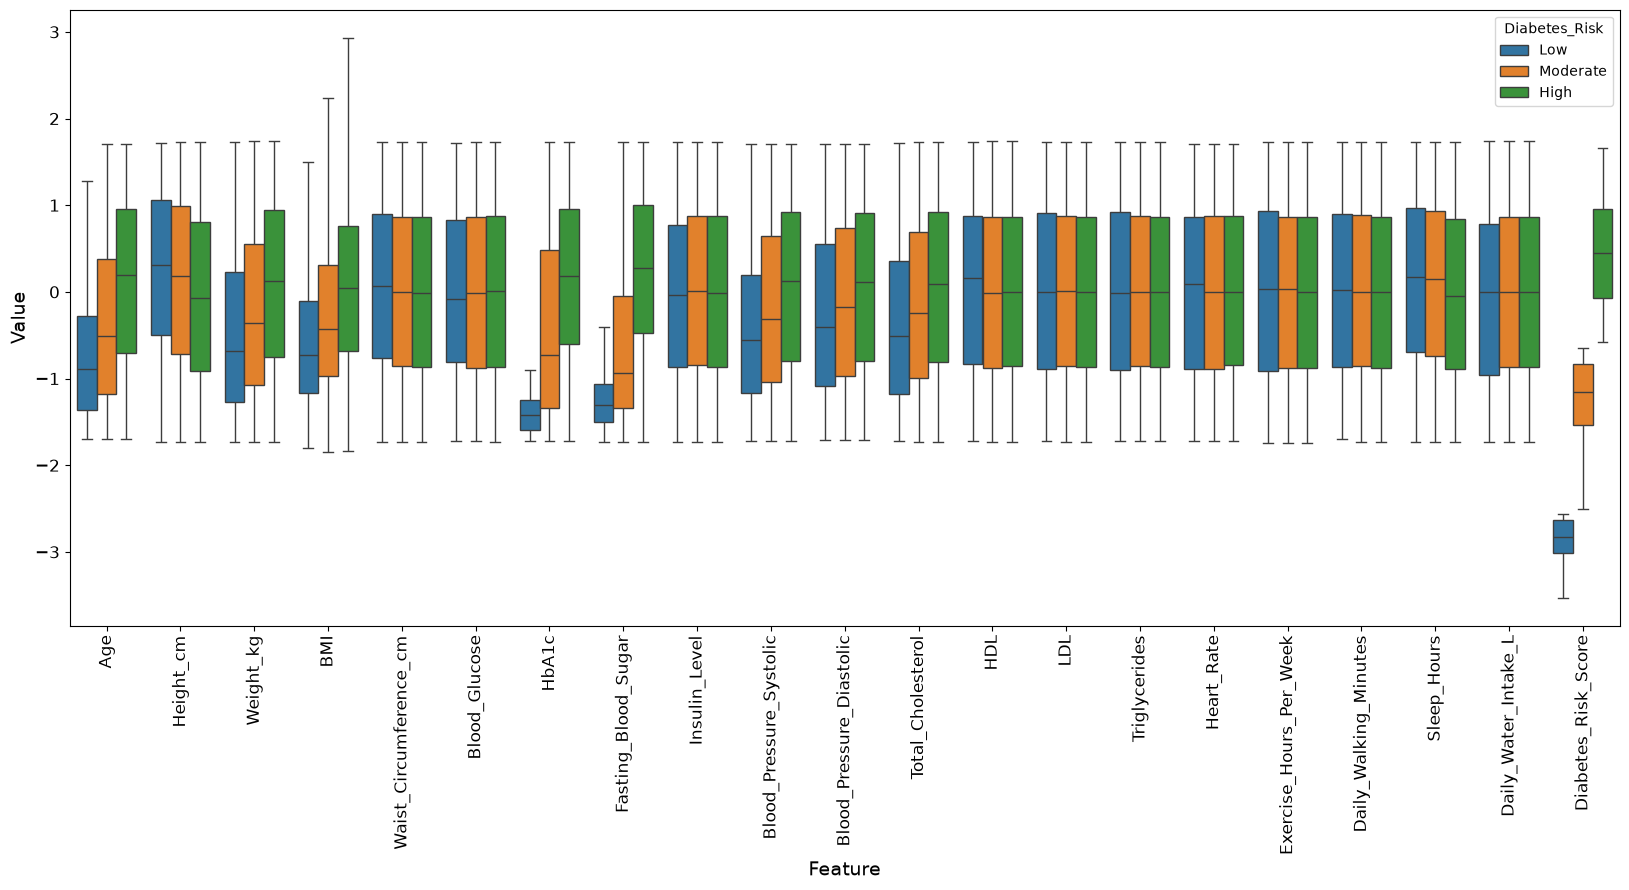

In [4]:
# Box plot to analyze distributions of numerical features based on low, moderate, or high diabetes risk

df[num_cols] = (df[num_cols] - df[num_cols].mean()) / df[num_cols].std()
df_melted_num = df.melt(id_vars="Diabetes_Risk", value_vars=num_cols, var_name="Feature", value_name="Value")

plt.figure(figsize=(20, 8))

sns.boxplot(data=df_melted_num, x="Feature", y="Value", hue="Diabetes_Risk", hue_order=["Low", "Moderate", "High"], showfliers=False)

plt.xlabel("Feature", fontsize=14)
plt.ylabel("Value", fontsize=14)

plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Prioritize numerical features where there are __larger separations__ in distribution between __low__, __moderate__, and __high__ diabetes risk:
1. Age
1. Height_cm
1. Weight_kg
1. HbA1c
1. Fasting_Blood_Sugar
1. Blood_Pressure_Systolic
1. Blood_Pressure_Diastolic
1. Total_Cholesterol
1. Sleep_Hours

### Categorical Data

In [ ]:
# Select columns that contain string data
cat_cols = df.select_dtypes(include='str').columns.tolist()
cat_cols

['Gender',
 'Country',
 'Physical_Activity_Level',
 'Diet_Quality',
 'Sugar_Intake_Level',
 'Stress_Level',
 'Smoking_Status',
 'Alcohol_Consumption',
 'Family_History_Diabetes',
 'Hypertension',
 'Heart_Disease',
 'Fatty_Liver',
 'PCOS',
 'Medication_Adherence',
 'Work_Type',
 'Residence_Type',
 'AI_Health_Recommendation',
 'Doctor_Consultation_Needed',
 'Diabetes_Risk']

In [ ]:
# Remove irrelevant columns

elements_to_remove = ["Gender", "Country", "Medication_Adherence", "Work_Type", "Residence_Type", "AI_Health_Recommendation", "Doctor_Consultation_Needed", "Diabetes_Risk"]

for element in elements_to_remove:
    if element in cat_cols:
        cat_cols.remove(element)
    
cat_cols

['Physical_Activity_Level',
 'Diet_Quality',
 'Sugar_Intake_Level',
 'Stress_Level',
 'Smoking_Status',
 'Alcohol_Consumption',
 'Family_History_Diabetes',
 'Hypertension',
 'Heart_Disease',
 'Fatty_Liver',
 'PCOS']

#### Categorical to Binary Data

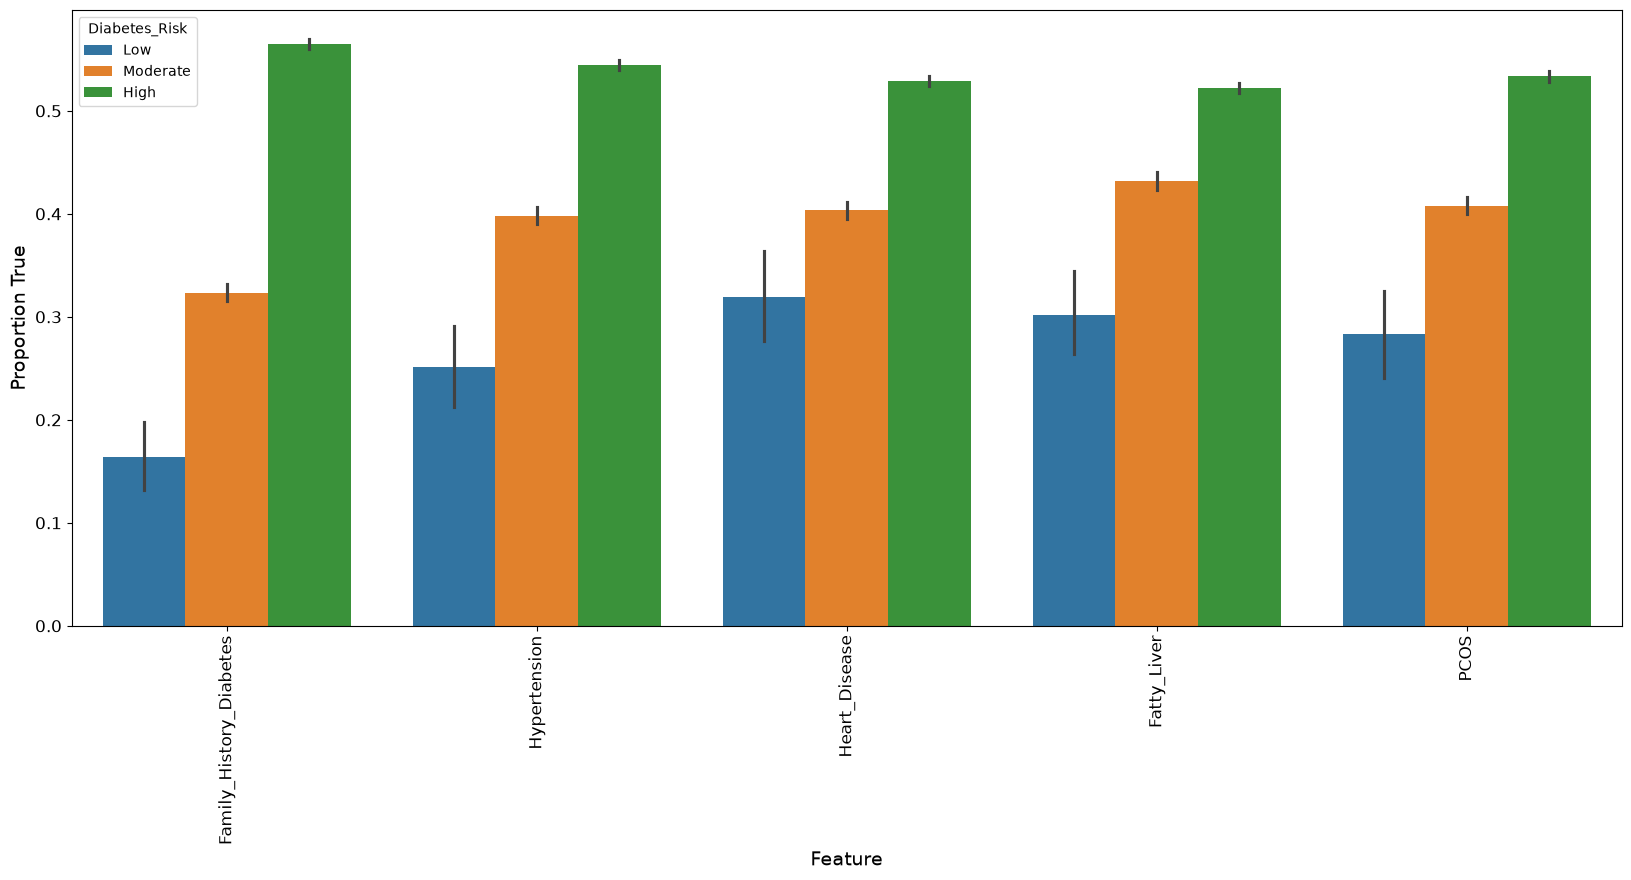

In [ ]:
# Analyze string columns that can be converted to binary data

bin_cols = ['Family_History_Diabetes', 'Hypertension', 'Heart_Disease', 'Fatty_Liver', 'PCOS']

df[bin_cols] = df[bin_cols].replace({"Yes": 1, "No": 0})

df_melted_bin = df.melt(id_vars="Diabetes_Risk", value_vars=bin_cols, var_name="Feature", value_name="Value")

# Bar plot shows percentage of patients who answer true to each of the features

plt.figure(figsize=(20, 8))

sns.barplot(data=df_melted_bin, x="Feature", y="Value", hue="Diabetes_Risk", hue_order=["Low", "Moderate", "High"], estimator="mean")

plt.xlabel("Feature", fontsize=14)
plt.ylabel("Proportion True", fontsize=14)

plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.show()

All 5 binary categorical features show distinct separations between __low__, __moderate__, and __high__ diabetes risk:
1. Family_History_Diabetes
1. Hypertension
1. Heart_Disease
1. Fatty_Liber
1. PCOS

##

### Final Columns List

In [8]:
cols = ["Age", "Height_cm", "Weight_kg", "HbA1c", "Fasting_Blood_Sugar", "Blood_Pressure_Systolic", "Blood_Pressure_Diastolic", "Total_Cholesterol", "Sleep_Hours"]